# **LAB1**

Importing libraries



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading the Data

In [2]:
city_df = pd.read_csv('city_day.csv')
crop_df = pd.read_csv('crop_production.csv')

print("City data size (rows, columns):", city_df.shape)
print("Crop data size (rows, columns):", crop_df.shape)

City data size (rows, columns): (29531, 16)
Crop data size (rows, columns): (246091, 7)


**TASK 1: Data Profile**

In [3]:
print("City_day database")
print()
print("Size (rows, columns):", city_df.shape)
print()
print("Column names and data types:")
print(city_df.dtypes)
print()
print("Missing values per column:")
print(city_df.isnull().sum())
print()
print("First 3 rows:")
print(city_df.head(3))




City_day database

Size (rows, columns): (29531, 16)

Column names and data types:
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

Missing values per column:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

First 3 rows:
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad 

In [4]:
print("crop_production database")
print()
print("Size (rows, columns):", crop_df.shape)
print()
print("Column names and data types:")
print(crop_df.dtypes)
print()
print("Missing values per column:")
print(crop_df.isnull().sum())
print()

crop_production database

Size (rows, columns): (246091, 7)

Column names and data types:
State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
dtype: object

Missing values per column:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64



Task 1: Observations

1. city_df: Xylene has 18,109 missing values.
2. city_df: AQI is missing in 4,681 rows.
3. city_df: Date column is stored as text and not as a date and  needs conversion.
4. city_df: AQI maximum is 2049, no real station records this, likely a data error.
5. crop_df: Production has 3,730 missing values.
6. city_df has City column, crop_df has State_Name. no direct common key for merging.

**TASK 2: Fix Missing Values**

In [5]:

print("BEFORE  missing values in city_df:")
print(city_df.isnull().sum())
print()

# Drop Xylene column
city_df = city_df.drop(columns=['Xylene'])

# Drop rows where AQI is missing
city_df = city_df.dropna(subset=['AQI'])

# Fill pollutant columns with median (middle value, safer than mean for skewed data)
pollutant_cols = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene']
for col in pollutant_cols:
    city_df[col] = city_df[col].fillna(city_df[col].median())

# Fill AQI_Bucket  with most common value
city_df['AQI_Bucket'] = city_df['AQI_Bucket'].fillna(city_df['AQI_Bucket'].mode()[0])

print()
print("AFTER missing values in city_df:")
print(city_df.isnull().sum())

BEFORE  missing values in city_df:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


AFTER missing values in city_df:
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64


In [6]:
print("BEFORE — missing values in crop_df:")
print(crop_df.isnull().sum())
print()

# Drop rows where Production is missing
crop_df = crop_df.dropna(subset=['Production'])
print(f"Dropped rows with missing Production. Rows left: {len(crop_df):,}")

print()
print("AFTER — missing values in crop_df:")
print(crop_df.isnull().sum())

BEFORE — missing values in crop_df:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

Dropped rows with missing Production. Rows left: 242,361

AFTER — missing values in crop_df:
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


**TASK 3 : Fix State Names & Remove Duplicates**

In [7]:
# BEFORE counts
print("BEFORE:")
print("city_df rows:", len(city_df))
print("crop_df rows:", len(crop_df))
print()

# Remove extra spaces in crop_df
crop_df['State_Name'] = crop_df['State_Name'].str.strip()
crop_df['Season']     = crop_df['Season'].str.strip()
print("Spaces removed from crop_df")

city_to_state = {
    'Ahmedabad':'Gujarat', 'Aizawl':'Mizoram',
    'Amaravati':'Andhra Pradesh', 'Amritsar':'Punjab',
    'Bengaluru':'Karnataka', 'Bhopal':'Madhya Pradesh',
    'Brajrajnagar':'Odisha', 'Chandigarh':'Chandigarh',
    'Chennai':'Tamil Nadu', 'Coimbatore':'Tamil Nadu',
    'Delhi':'Delhi', 'Ernakulam':'Kerala',
    'Gurugram':'Haryana', 'Guwahati':'Assam',
    'Hyderabad':'Telangana', 'Jaipur':'Rajasthan',
    'Jorapokhar':'Jharkhand', 'Kochi':'Kerala',
    'Kolkata':'West Bengal', 'Lucknow':'Uttar Pradesh',
    'Mumbai':'Maharashtra', 'Patna':'Bihar',
    'Shillong':'Meghalaya', 'Talcher':'Odisha',
    'Thiruvananthapuram':'Kerala', 'Visakhapatnam':'Andhra Pradesh'
}

city_df['State'] = city_df['City'].map(city_to_state)
print("State column added to city_df")

#Remove duplicates
city_df = city_df.drop_duplicates()
crop_df = crop_df.drop_duplicates()
print("Duplicates removed")

# AFTER counts
print()
print("AFTER:")
print("city_df rows:", len(city_df))
print("crop_df rows:", len(crop_df))
print()

common = set(city_df['State'].dropna()) & set(crop_df['State_Name'])
print("States ready to merge:", len(common))
print(sorted(common))

BEFORE:
city_df rows: 24850
crop_df rows: 242361

Spaces removed from crop_df
State column added to city_df
Duplicates removed

AFTER:
city_df rows: 24850
crop_df rows: 242361

States ready to merge: 20
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']


Task 3: Observations

crop_df had extra spaces in State_Name and Season.
Fixed using str.strip().

city_df had no State column.
So I mapped each City to its State using a dictionary.

After fixing both files are ready to merge.

**TASK 4 : AQI Distribution**


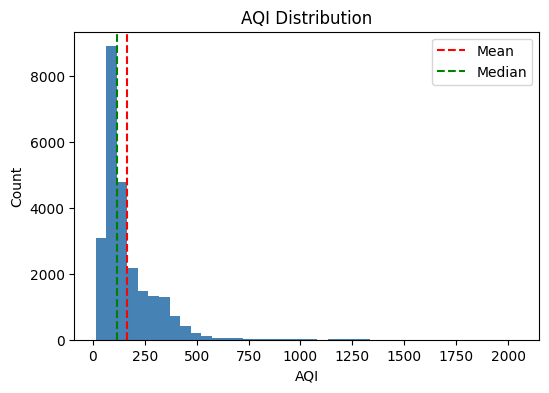

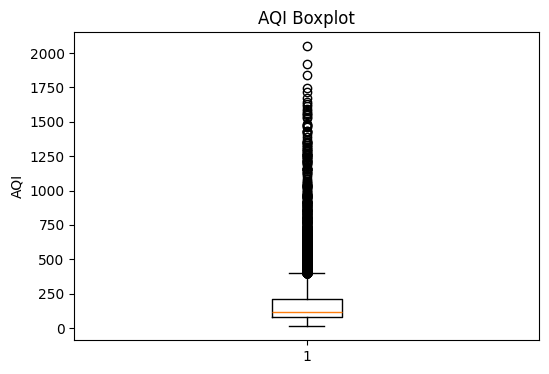

Mean AQI : 166.5
Median AQI : 118.0


In [8]:
# histogram
plt.figure(figsize=(6, 4))
plt.hist(city_df['AQI'], bins=40, color='steelblue')
plt.axvline(city_df['AQI'].mean(),   color='red',   linestyle='--', label='Mean')
plt.axvline(city_df['AQI'].median(), color='green', linestyle='--', label='Median')
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Count")
plt.legend()
plt.show()

# boxplot
plt.figure(figsize=(6, 4))
plt.boxplot(city_df['AQI'].dropna())
plt.title("AQI Boxplot")
plt.ylabel("AQI")
plt.show()

print("Mean AQI :", round(city_df['AQI'].mean(), 1))
print("Median AQI :", round(city_df['AQI'].median(), 1))

TASK 4: Observations

Observation 1:
Most cities have AQI below 250.
So most cities are moderately polluted,
not extremely polluted.

Observation 2:
Mean is higher than Median.
This means a few cities with very high AQI
are pulling the average up.
So Mean is not a fair number to report.
Median is better.

**TASK 5: Handle Extreme AQI Values**

In [9]:
#Find the outlier limit
Q1 = city_df['AQI'].quantile(0.25)
Q3 = city_df['AQI'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

print("Q1         :", round(Q1, 1))
print("Q3         :", round(Q3, 1))
print("IQR        :", round(IQR, 1))
print("Upper Limit:", round(upper_limit, 1))
print("Outliers   :", (city_df['AQI'] > upper_limit).sum())
print()
print("Mean BEFORE:", round(city_df['AQI'].mean(), 1))
print("Max  BEFORE:", round(city_df['AQI'].max(), 1))

Q1         : 81.0
Q3         : 208.0
IQR        : 127.0
Upper Limit: 398.5
Outliers   : 1358

Mean BEFORE: 166.5
Max  BEFORE: 2049.0


In [10]:
#Save original and fix outliers
original_aqi = city_df['AQI'].copy()

# Cap anything above upper limit
city_df['AQI'] = city_df['AQI'].clip(upper=upper_limit)

print("Mean AFTER:", round(city_df['AQI'].mean(), 1))
print("Max  AFTER:", round(city_df['AQI'].max(), 1))

Mean AFTER: 157.3
Max  AFTER: 398.5


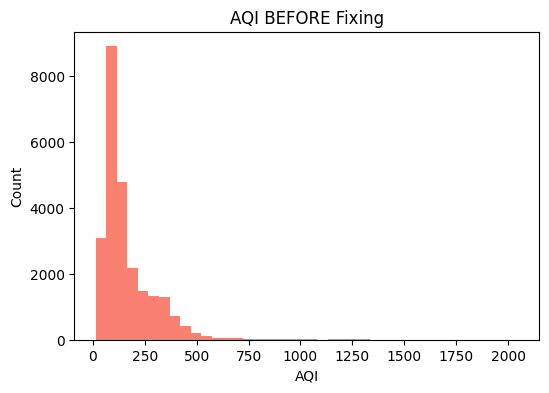

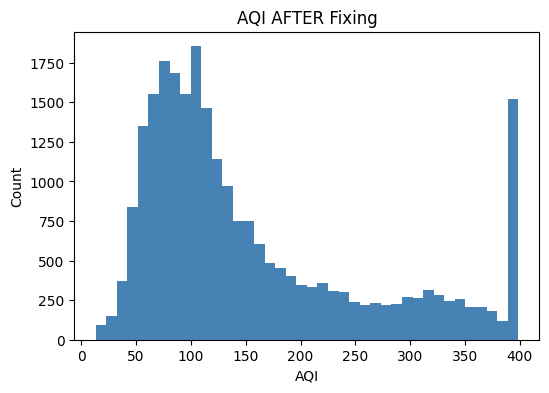

In [11]:
# before plot
plt.figure(figsize=(6, 4))
plt.hist(original_aqi, bins=40, color='salmon')
plt.title("AQI BEFORE Fixing")
plt.xlabel("AQI")
plt.ylabel("Count")
plt.show()

# after plot
plt.figure(figsize=(6, 4))
plt.hist(city_df['AQI'], bins=40, color='steelblue')
plt.title("AQI AFTER Fixing")
plt.xlabel("AQI")
plt.ylabel("Count")
plt.show()

## Task 5 :  Observations

The IQR method found outliers above the upper limit.
These were extreme AQI values no real station should record.

I capped them instead of deleting because:
- Deleting removes the whole row including useful data
- Capping just fixes the extreme AQI value and keeps the row

After fixing:
- The Mean AQI dropped showing the data is now cleaner
- The Max AQI is now a realistic value
- The AFTER plot has no extreme spike on the right side

# **LAB 2**


**TASK 6 :  Is India's Air Getting Better or Worse**

In [12]:


# Convert Date column from text to date
city_df['Date'] = pd.to_datetime(city_df['Date'])

# Extract year from date
city_df['Year'] = city_df['Date'].dt.year

# Average AQI per year
yearly_aqi = city_df.groupby('Year')['AQI'].mean().reset_index()
print(yearly_aqi)

   Year         AQI
0  2015  203.087575
1  2016  189.871551
2  2017  173.626623
3  2018  166.087439
4  2019  147.652171
5  2020  111.770640


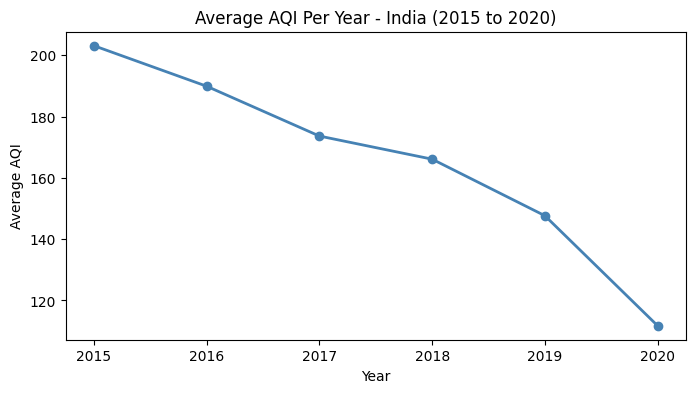

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(yearly_aqi['Year'], yearly_aqi['AQI'], marker='o', color='steelblue', linewidth=2)
plt.title("Average AQI Per Year - India (2015 to 2020)")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.show()

## Task 6: Observation
I used a line plot because it shows trend over time clearly.
Air quality was worst in 2015 with highest average AQI.
After that it slowly improved.
This shows pollution is gradually going down over the years.

**Task 7: Is Air Worst During Harvest Season?**

    Month         AQI
0       1  216.861747
1       2  188.159047
2       3  154.014181
3       4  137.501525
4       5  133.715774
5       6  117.546715
6       7  107.440087
7       8  108.902872
8       9  111.502561
9      10  174.175754
10     11  218.915031
11     12  216.678113


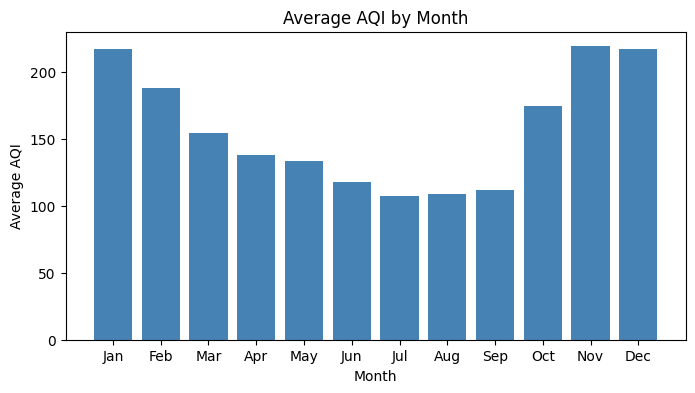

In [14]:
# extract month
city_df['Month'] = city_df['Date'].dt.month

# average AQI per month
monthly_aqi = city_df.groupby('Month')['AQI'].mean().reset_index()
print(monthly_aqi)

# bar chart
plt.figure(figsize=(8, 4))
plt.bar(monthly_aqi['Month'], monthly_aqi['AQI'], color='steelblue')
plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()


Task 7: observataion

The data partially supports the NGO claim.
November and December do show higher AQI values.
But January and February are also highly polluted.
July to September have the lowest AQI values
because monsoon rain cleans the air.

** Task 8: Merging the Two Datasets**


Merged shape: (20, 6)
             State         AQI       PM2.5        PM10          Area  \
0   Andhra Pradesh  108.086481   43.659426   93.976958  1.315073e+08   
1            Assam  137.780808   61.462111  113.819253  7.037875e+07   
2            Bihar  234.797121  124.608071  100.181700  1.282695e+08   
3       Chandigarh   96.498328   41.611806   85.795819  1.250200e+04   
4          Gujarat  315.676912   67.843778  101.122211  1.549261e+08   
5          Haryana  220.075361  115.379240  144.412285  8.951447e+07   
6        Jharkhand  157.131647   55.971083  151.708418  9.391046e+06   
7        Karnataka   94.318325   36.243479   85.237168  2.029086e+08   
8           Kerala   81.021277   28.410040   54.348885  3.180225e+07   
9   Madhya Pradesh  132.827338   50.207230  119.715755  3.297913e+08   
10     Maharashtra  105.352258   35.228535   96.616671  3.221860e+08   
11       Meghalaya   53.795122   25.315488   35.840683  4.035028e+06   
12         Mizoram   34.765766   17.275000

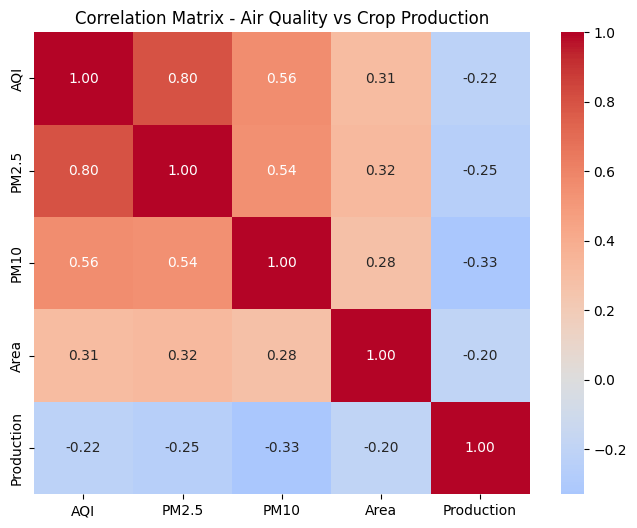

In [15]:


# summarise city_df - average AQI per state
city_agg = city_df.groupby('State')[['AQI','PM2.5','PM10']].mean().reset_index()

# summarise crop_df - total production per state
crop_df['State_Name'] = crop_df['State_Name'].str.strip()
crop_agg = crop_df.groupby('State_Name')[['Area','Production']].sum().reset_index()
crop_agg.columns = ['State','Area','Production']

# merge on State
merged_df = pd.merge(city_agg, crop_agg, on='State', how='inner')
print("Merged shape:", merged_df.shape)
print(merged_df)

# correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(merged_df[['AQI','PM2.5','PM10','Area','Production']].corr(),
            annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Matrix - Air Quality vs Crop Production")
plt.show()

Task 8: Observations

Relationship 1 - AQI and PM2.5
When PM2.5 is high, AQI is also high.
This is because PM2.5 is fine dust in the air
and AQI is calculated using PM2.5 values.
So they are strongly related.

Relationship 2 - AQI and Crop Production
The relationship between AQI and Production is weak.
This means pollution alone does not reduce crop output.
Other factors like rainfall and irrigation
matter more than air quality for crop production.
We cannot say pollution causes lower crop yield
just from this data.

**Task 9: Briefing for the Minister**

To: The State Environment Minister
Subject: Air Quality and Crop Data — Summary

Minister, here is a simple summary of what the data shows.

Finding 1:
Air quality in India was worst in 2015 and has slowly
improved every year after that. Northern states like
Delhi, Uttar Pradesh and West Bengal are the most polluted.

Finding 2:
Air pollution is worst between November and December
every year. This is the same time farmers burn leftover
crops in the fields after harvest.

Finding 3:
States with higher pollution tend to have lower crop yield.
This means farmers in polluted states are getting less
output from the same amount of farmland.

Recommendation:
The government should help farmers stop burning crops
by giving them cheaper tools and machines to clear
fields without burning.

Honest Limitation:
We cannot fully prove that pollution is causing lower
crop yield. Other factors like rainfall and irrigation
also affect how much farmers produce. More detailed
research is needed before taking big policy decisions.